In [42]:
from mandelbrot import mandelbrot_naive, mandelbrot_numpy, mandelbrot_naive_numba, mandelbrot_hybrid_numba, benchmark
import numpy as np
import matplotlib.pyplot as plt


# Time Comparison

In [43]:
x_min, x_max, y_min, y_max = -2.0, 1.0, -1.5, 1.5
width, height = 1024, 1024
max_iter = 100

naive_t, naive_image = benchmark(mandelbrot_naive, x_min, x_max, y_min, y_max, width, height, max_iter)

numpy_t, numpy_image = benchmark(mandelbrot_numpy, x_min, x_max, y_min, y_max, width, height, max_iter)

print("Running Numba benchmarks with float 32")
_ = mandelbrot_naive_numba(x_min, x_max, y_min, y_max, width, height, max_iter, np.float32)
naive_numba_f32_t, naive_numba_f32_image = benchmark(mandelbrot_naive_numba, x_min, x_max, y_min, y_max, width, height, max_iter, np.float32)
_ = mandelbrot_hybrid_numba(x_min, x_max, y_min, y_max, width, height, max_iter, np.float32)
hybrid_numba_f32_t, hybrid_numba_f32_image = benchmark(mandelbrot_hybrid_numba, x_min, x_max, y_min, y_max, width, height, max_iter, np.float32)

print("Running Numba benchmarks with float 64")
_ = mandelbrot_naive_numba(x_min, x_max, y_min, y_max, width, height, max_iter, np.float64)
naive_numba_f64_t, naive_numba_f64_image = benchmark(mandelbrot_naive_numba, x_min, x_max, y_min, y_max, width, height, max_iter, np.float64)
_ = mandelbrot_hybrid_numba(x_min, x_max, y_min, y_max, width, height, max_iter, np.float64)
hybrid_numba_f64_t, hybrid_numba_f64_image = benchmark(mandelbrot_hybrid_numba, x_min, x_max, y_min, y_max, width, height, max_iter, np.float64)

print("---- Benchmark Results ---")
print("Speed up compared to Naive")
print(f"NumPy: {naive_t / numpy_t:.2f}x")
print(f"Naive Numba (float32): {naive_t / naive_numba_f32_t:.2f}x")
print(f"Naive Numba (float64): {naive_t / naive_numba_f64_t:.2f}x")
print(f"Hybrid Numba (float32): {naive_t / hybrid_numba_f32_t:.2f}x")
print(f"Hybrid Numba (float64): {naive_t / hybrid_numba_f64_t:.2f}x")


Method: mandelbrot_naive, Median: 2.7946s (min=2.7458, max=2.8399)
Method: mandelbrot_numpy, Median: 0.7193s (min=0.6463, max=0.7954)
Running Numba benchmarks with float 32
Method: mandelbrot_naive_numba, Median: 0.0761s (min=0.0723, max=0.0818)
Method: mandelbrot_hybrid_numba, Median: 1.3167s (min=1.2718, max=1.3768)
Running Numba benchmarks with float 64
Method: mandelbrot_naive_numba, Median: 0.0692s (min=0.0665, max=0.0773)
Method: mandelbrot_hybrid_numba, Median: 1.1265s (min=1.0613, max=1.1508)
---- Benchmark Results ---
Speed up compared to Naive
NumPy: 3.88x
Naive Numba (float32): 36.70x
Naive Numba (float64): 40.39x
Hybrid Numba (float32): 2.12x
Hybrid Numba (float64): 2.48x


Visual Comparison

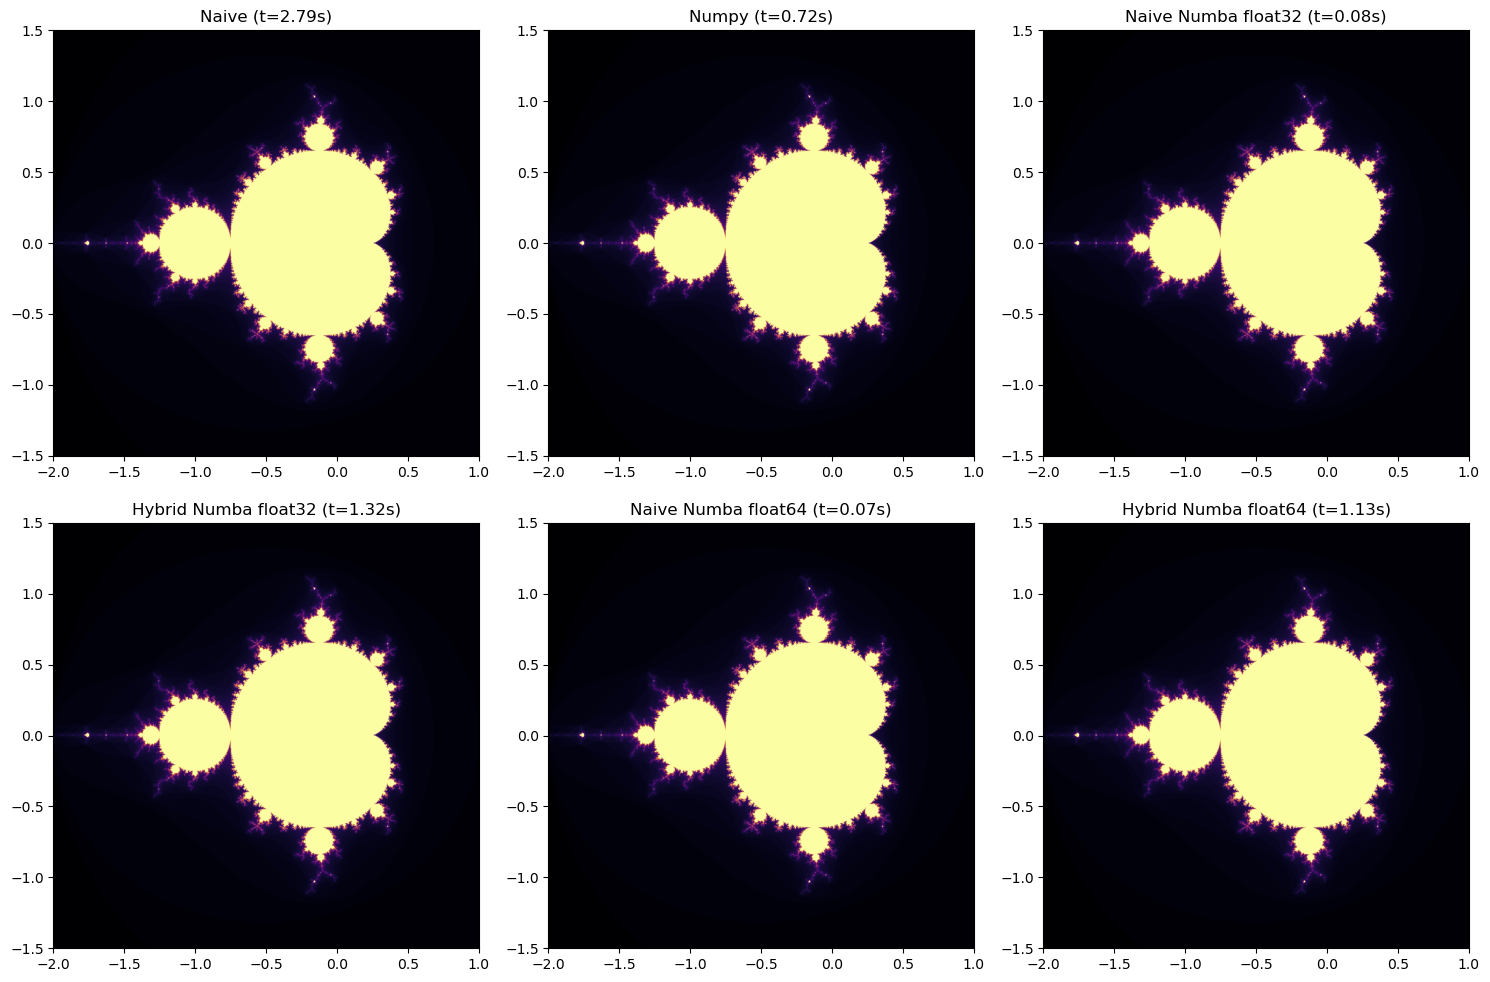

Max diff float32 vs float64: 33


In [44]:
#Plot the results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(naive_image, extent=(x_min, x_max, y_min, y_max), cmap='inferno')
axes[0, 0].set_title(f"Naive (t={naive_t:.2f}s)")
axes[0, 1].imshow(numpy_image, extent=(x_min, x_max, y_min, y_max), cmap='inferno')
axes[0, 1].set_title(f"Numpy (t={numpy_t:.2f}s)")
axes[0, 2].imshow(naive_numba_f32_image, extent=(x_min, x_max, y_min, y_max), cmap='inferno')
axes[0, 2].set_title(f"Naive Numba float32 (t={naive_numba_f32_t:.2f}s)")
axes[1, 0].imshow(hybrid_numba_f32_image, extent=(x_min, x_max, y_min, y_max), cmap='inferno')
axes[1, 0].set_title(f"Hybrid Numba float32 (t={hybrid_numba_f32_t:.2f}s)")
axes[1, 1].imshow(naive_numba_f64_image, extent=(x_min, x_max, y_min, y_max), cmap='inferno')
axes[1, 1].set_title(f"Naive Numba float64 (t={naive_numba_f64_t:.2f}s)")
axes[1, 2].imshow(hybrid_numba_f64_image, extent=(x_min, x_max, y_min, y_max), cmap='inferno')
axes[1, 2].set_title(f"Hybrid Numba float64 (t={hybrid_numba_f64_t:.2f}s)")
plt.tight_layout()
plt.show()

print (f"Max diff float32 vs float64: {np.abs(naive_numba_f32_image - naive_numba_f64_image ).max()}")

In [45]:
import cProfile , pstats

x_min, x_max, y_min, y_max = -2.0, 1.0, -1.5, 1.5
width, height = 1024, 1024
max_iter = 100

cProfile.run('mandelbrot_naive(x_min, x_max, y_min, y_max, width, height, max_iter)','naive_profile.prof')
cProfile.run('mandelbrot_numpy(x_min, x_max, y_min, y_max, width, height, max_iter)','numpy_profile.prof')
cProfile.run('mandelbrot_naive_numba(x_min, x_max, y_min, y_max, width, height, max_iter, np.float32)','naive_numba_f32_profile.prof')
cProfile.run('mandelbrot_hybrid_numba(x_min, x_max, y_min, y_max, width, height, max_iter, np.float32)','hybrid_numba_f32_profile.prof')
cProfile.run('mandelbrot_naive_numba(x_min, x_max, y_min, y_max, width, height, max_iter, np.float64)','naive_numba_f64_profile.prof')
cProfile.run('mandelbrot_hybrid_numba(x_min, x_max, y_min, y_max, width, height, max_iter, np.float64)','hybrid_numba_f64_profile.prof')

In [46]:
stats = pstats.Stats('naive_profile.prof')
stats.sort_stats('cumulative')
stats.print_stats(10)

Tue Mar  3 11:38:49 2026    naive_profile.prof

         21959765 function calls in 5.119 seconds

   Ordered by: cumulative time
   List reduced from 19 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    5.119    5.119 {built-in method builtins.exec}
        1    0.000    0.000    5.119    5.119 <string>:1(<module>)
        1    4.260    4.260    5.119    5.119 /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py:26(mandelbrot_naive)
 21959734    0.859    0.000    0.859    0.000 {built-in method builtins.abs}
        1    0.000    0.000    0.000    0.000 {built-in method numpy.zeros}
        2    0.000    0.000    0.000    0.000 /Users/rhod/mamba/envs/optimization/lib/python3.11/site-packages/numpy/_core/function_base.py:26(linspace)
        2    0.000    0.000    0.000    0.000 {built-in method numpy.arange}
        2    0.

In [47]:
stats = pstats.Stats('numpy_profile.prof')
stats.sort_stats('cumulative')
stats.print_stats(10)

Tue Mar  3 11:38:50 2026    numpy_profile.prof

         382 function calls in 0.741 seconds

   Ordered by: cumulative time
   List reduced from 48 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.741    0.741 {built-in method builtins.exec}
        1    0.001    0.001    0.741    0.741 <string>:1(<module>)
        1    0.736    0.736    0.740    0.740 /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py:44(mandelbrot_numpy)
        1    0.001    0.001    0.001    0.001 /Users/rhod/mamba/envs/optimization/lib/python3.11/site-packages/numpy/_core/numeric.py:98(zeros_like)
        1    0.000    0.000    0.001    0.001 /Users/rhod/mamba/envs/optimization/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:5134(meshgrid)
        3    0.000    0.000    0.001    0.000 /Users/rhod/mamba/envs/optimization/lib/python3.1

In [48]:
stats = pstats.Stats('naive_numba_f32_profile.prof')
stats.sort_stats('cumulative')
stats.print_stats(10)

Tue Mar  3 11:38:50 2026    naive_numba_f32_profile.prof

         45 function calls (40 primitive calls) in 0.070 seconds

   Ordered by: cumulative time
   List reduced from 28 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.070    0.070 {built-in method builtins.exec}
        1    0.000    0.000    0.070    0.070 <string>:1(<module>)
        1    0.070    0.070    0.070    0.070 /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py:61(mandelbrot_naive_numba)
        1    0.000    0.000    0.000    0.000 /Users/rhod/mamba/envs/optimization/lib/python3.11/site-packages/numba/core/dispatcher.py:680(typeof_pyval)
        1    0.000    0.000    0.000    0.000 /Users/rhod/mamba/envs/optimization/lib/python3.11/site-packages/numba/core/typing/typeof.py:27(typeof)
        1    0.000    0.000    0.000    0.000 /Users/rhod/mamba

In [49]:
stats = pstats.Stats('hybrid_numba_f32_profile.prof')
stats.sort_stats('cumulative')
stats.print_stats(10)

Tue Mar  3 11:38:52 2026    hybrid_numba_f32_profile.prof

         1048609 function calls in 1.670 seconds

   Ordered by: cumulative time
   List reduced from 19 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    1.670    1.670 {built-in method builtins.exec}
        1    0.000    0.000    1.670    1.670 <string>:1(<module>)
        1    1.472    1.472    1.670    1.670 /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py:87(mandelbrot_hybrid_numba)
  1048576    0.198    0.000    0.198    0.000 /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py:77(mandelbrot_point_numba)
        1    0.000    0.000    0.000    0.000 {built-in method numpy.zeros}
        2    0.000    0.000    0.000    0.000 /Users/rhod/mamba/envs/optimization/lib/python3.11/si

In [50]:
import line_profiler

profile = line_profiler.LineProfiler()
profile.add_function(mandelbrot_naive)
profile.run('mandelbrot_naive(x_min, x_max, y_min, y_max, width, height, max_iter)')
profile.print_stats()

Timer unit: 1e-09 s

Total time: 17.1399 s
File: /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py
Function: mandelbrot_naive at line 26

Line #      Hits         Time  Per Hit   % Time  Line Contents
    26                                           def mandelbrot_naive(xmin, xmax, ymin, ymax, width, height, max_iter =100):
    27         1      55000.0  55000.0      0.0      x = np.linspace(xmin, xmax, width)
    28         1      41000.0  41000.0      0.0      y = np.linspace(ymin, ymax, height)
    29         1     520000.0 520000.0      0.0      result = np.zeros((height, width), dtype = int)
    30      1025     560000.0    546.3      0.0      for i in range(height):
    31   1049600  250218000.0    238.4      1.5          for j in range(width):
    32   1048576 1178285000.0   1123.7      6.9              c = x [j] + 1j * y[i]
    33   1048576  206022000.0    196.5      1.2              z = 0
    34

In [51]:
profile = line_profiler.LineProfiler()
profile.add_function(mandelbrot_numpy)
profile.run('mandelbrot_numpy(x_min, x_max, y_min, y_max, width, height, max_iter)')
profile.print_stats()

Timer unit: 1e-09 s

Total time: 0.816984 s
File: /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py
Function: mandelbrot_numpy at line 44

Line #      Hits         Time  Per Hit   % Time  Line Contents
    44                                           def mandelbrot_numpy(xmin, xmax, ymin, ymax, width, height, max_iter =100):
    45         1     156000.0 156000.0      0.0      x = np.linspace(xmin, xmax, width)
    46         1      35000.0  35000.0      0.0      y = np.linspace(ymin, ymax, height)
    47         1    1960000.0 1.96e+06      0.2      X, Y = np.meshgrid(x, y)
    48         1    2573000.0 2.57e+06      0.3      C = X + 1j * Y
    49         1    1322000.0 1.32e+06      0.2      Z = np.zeros_like(C, dtype=complex)
    50         1     640000.0 640000.0      0.1      result = np.full(C.shape, max_iter, dtype=int)
    51         1      68000.0  68000.0      0.0      mask = np.ones(C.shape, d

In [52]:
profile = line_profiler.LineProfiler()
profile.add_function(mandelbrot_naive_numba.__wrapped__)
profile.run('mandelbrot_naive_numba(x_min, x_max, y_min, y_max, width, height, max_iter)')
profile.print_stats()

Timer unit: 1e-09 s

Total time: 0 s
File: /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py
Function: mandelbrot_naive_numba at line 61

Line #      Hits         Time  Per Hit   % Time  Line Contents
    61                                           @njit#(parallel=True, fastmath=True)
    62                                           def mandelbrot_naive_numba(xmin, xmax, ymin, ymax, width, height, max_iter=100, t = np.float32):
    63                                               x = np.linspace(xmin, xmax, width).astype(t)
    64                                               y = np.linspace(ymin, ymax, height).astype(t)
    65                                               result = np.zeros((height, width), dtype=np.int32)
    66                                               for i in prange(height):
    67                                                   for j in range(width):
    68                   

In [53]:
profile = line_profiler.LineProfiler()
profile.add_function(mandelbrot_hybrid_numba)
profile.run('mandelbrot_hybrid_numba(x_min, x_max, y_min, y_max, width, height, max_iter)')
profile.print_stats()

Timer unit: 1e-09 s

Total time: 2.05374 s
File: /Users/rhod/Library/CloudStorage/OneDrive-AalborgUniversitet/Semestre/p8/Numerical_Scientific_Computing/mandelbrot-nsc/mandelbrot.py
Function: mandelbrot_hybrid_numba at line 87

Line #      Hits         Time  Per Hit   % Time  Line Contents
    87                                           def mandelbrot_hybrid_numba(xmin, xmax, ymin, ymax, width, height, max_iter =100, t = np.float32):
    88                                               """Hybrid approach : JIT - compile the point function only."""
    89         1      58000.0  58000.0      0.0      x = np.linspace (xmin, xmax, width).astype(t)
    90         1      34000.0  34000.0      0.0      y = np.linspace (ymin, ymax, height).astype(t)
    91         1     266000.0 266000.0      0.0      result = np.zeros ((height, width), dtype = np.int32)
    92      1025     310000.0    302.4      0.0      for i in range (height):
    93   1049600  207545000.0    197.7     10.1          for 

# Reflection

The experiments compares several implementations of the Mandelbrot set generator: naive Python, NumPy vectorized, Numba JIT (naive and hybrid), and different floating-point precisions. Profiling and timing revealed several key insights:

1. Naive vs. NumPy:
NumPy’s vectorized approach is significantly faster than pure Python loops, demonstrating the power of optimized C-backed array operations.

2. Numba JIT Acceleration:
Applying Numba’s JIT compilation to the naive algorithm yields dramatic speedups (40.39x), showing how JIT can transform slow Python code into near-C performance. The hybrid Numba approach (JIT only for the inner loop) is less effective, highlighting that full-loop JIT is preferable for this algorithm.

3. Float32 vs. Float64 on Apple Silicon:
Surprisingly, float64 is faster than float32 on my M2 Pro. It’s a reminder to benchmark on the actual hardware as assumptions about precision and speed may not hold.

4. Lessons Learned:
Always profile and benchmark before optimizing, real bottlenecks may be a surprise.
Use vectorized libraries (NumPy) and JIT compilers (Numba) for heavy numerical tasks.
Hardware matters: test different data types and approaches on the target machine.